# PARTIE B:  Machine Learning : Prediction d'un accouchement assisté par un persnonnel qualifié au Cameroun


## 1. Importation des bibliothèques

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Sélection et évaluation
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)
from sklearn.metrics import roc_auc_score, accuracy_score

print('Bibliothèques importées avec succès.')

Bibliothèques importées avec succès.


## 2. Chargement et préparation des données

In [20]:
# Chargement du fichier exporté par le notebook d'analyse statistique
data = pd.read_csv('PrCMIR71FL.csv', sep=';')
print(f'Dimensions initiales : {data.shape}')
data.head()

Dimensions initiales : (5013, 18)


,CASEID,V005,V021,V023,V013,V024,V025,V106,V130,V190,V701,SBA,ANC,Media_exposure,autonomie_decisionnelle,attitude_violence,poids_final,parite
0,1 125 2,990064,1,8,4,5,1,2,1,2,0.0,1,1,0,3.0,0,0.990064,2
1,1 147 2,990064,1,8,2,5,1,2,4,4,2.0,1,1,1,3.0,1,0.990064,1
2,1 191 3,990064,1,8,2,5,1,1,4,3,0.0,1,1,0,1.0,0,0.990064,1
3,1 198 1,990064,1,8,3,5,1,1,2,3,2.0,0,1,1,2.0,1,0.990064,2
4,1 252 2,990064,1,8,5,5,1,0,4,3,2.0,0,1,0,2.0,0,0.990064,3


In [21]:
data.dtypes

CASEID                      object
V005                         int64
V021                         int64
V023                         int64
V013                         int64
V024                         int64
V025                         int64
V106                         int64
V130                         int64
V190                         int64
V701                       float64
SBA                          int64
ANC                          int64
Media_exposure               int64
autonomie_decisionnelle    float64
attitude_violence            int64
poids_final                float64
parite                       int64
dtype: object

In [22]:
# reconversion de certain types
# Liste des variables qui sont en réalité des catégories
variables_catégorielles = [
    'V013', 'V024', 'V025', 'V106', 'V130', 'V190', 'V701', 
     'ANC', 'Media_exposure', 'autonomie_decisionnelle', 'attitude_violence'
]

# Boucle pour convertir chaque colonne en type 'category'
for col in variables_catégorielles:
    data[col] = data[col].astype('category')

# Vérification du nouveau dtypes
print(data.dtypes)

CASEID                       object
V005                          int64
V021                          int64
V023                          int64
V013                       category
V024                       category
V025                       category
V106                       category
V130                       category
V190                       category
V701                       category
SBA                           int64
ANC                        category
Media_exposure             category
autonomie_decisionnelle    category
attitude_violence          category
poids_final                 float64
parite                        int64
dtype: object


In [23]:
data.isna().sum()

CASEID                     0
V005                       0
V021                       0
V023                       0
V013                       0
V024                       0
V025                       0
V106                       0
V130                       0
V190                       0
V701                       0
SBA                        0
ANC                        0
Media_exposure             0
autonomie_decisionnelle    0
attitude_violence          0
poids_final                0
parite                     0
dtype: int64

In [24]:
# Liste des variables catégorielles à transformer (exclure SBA et variables d'identification)
cat_vars = ['V013', 'V024', 'V025', 'V106', 'V130', 'V190', 'V701', 
            'ANC', 'Media_exposure', 'autonomie_decisionnelle', 'attitude_violence', 'parite']

# Créer les dummies avec drop_first=True (supprime la première modalité)
# Pour que la référence soit celle que vous souhaitez, il faut d'abord réordonner les catégories.
# Exemple pour V013 : placer la catégorie '1' en première position.
# On peut définir un ordre personnalisé pour chaque variable.

# Définir l'ordre souhaité (la première sera la référence)
custom_order = {
    'V013': [1,2,3,4,5,6,7],
    'V024': [5,1,2,3,4,6,7,8,9,10,11,12],  # 5 = Extrême-Nord en référence
    'V025': [2,1],
    'V106': [0,1,2,3],
    'V130': [4,1,2,3,5,7,96],  # 4 = Musulman en référence
    'V190': [1,2,3,4,5],
    'V701': [0,1,2,3,8],
    'ANC': [0,1],
    'Media_exposure': [0,1],
    'autonomie_decisionnelle': [1,2,3],
    'attitude_violence': [1,0],
    'parite': [3,1,2]
}

# Appliquer l'ordre personnalisé puis créer les dummies
data_dummies = data.copy()
for var in cat_vars:
    # Convertir en catégorie ordonnée
    data_dummies[var] = pd.Categorical(data_dummies[var], categories=custom_order[var], ordered=True)
    # Créer les dummies (drop_first=True supprime la première catégorie)
    dummies = pd.get_dummies(data_dummies[var], prefix=var, drop_first=True)
    # Ajouter au dataframe
    data_dummies = pd.concat([data_dummies, dummies], axis=1)
    # Optionnel : supprimer la colonne originale
    # df_dummies.drop(columns=[var], inplace=True)

# Vérifier les nouvelles colonnes
print([col for col in data_dummies.columns if 'V013_' in col])

['V013_2', 'V013_3', 'V013_4', 'V013_5', 'V013_6', 'V013_7']


In [25]:
data_dummies.shape

(5013, 60)

In [26]:
data_dummies.columns

Index(['CASEID', 'V005', 'V021', 'V023', 'V013', 'V024', 'V025', 'V106',
       'V130', 'V190', 'V701', 'SBA', 'ANC', 'Media_exposure',
       'autonomie_decisionnelle', 'attitude_violence', 'poids_final', 'parite',
       'V013_2', 'V013_3', 'V013_4', 'V013_5', 'V013_6', 'V013_7', 'V024_1',
       'V024_2', 'V024_3', 'V024_4', 'V024_6', 'V024_7', 'V024_8', 'V024_9',
       'V024_10', 'V024_11', 'V024_12', 'V025_1', 'V106_1', 'V106_2', 'V106_3',
       'V130_1', 'V130_2', 'V130_3', 'V130_5', 'V130_7', 'V130_96', 'V190_2',
       'V190_3', 'V190_4', 'V190_5', 'V701_1', 'V701_2', 'V701_3', 'V701_8',
       'ANC_1', 'Media_exposure_1', 'autonomie_decisionnelle_2',
       'autonomie_decisionnelle_3', 'attitude_violence_0', 'parite_1',
       'parite_2'],
      dtype='object')

In [27]:
data_dummies.isna().sum()

CASEID                       0
V005                         0
V021                         0
V023                         0
V013                         0
V024                         0
V025                         0
V106                         0
V130                         0
V190                         0
V701                         0
SBA                          0
ANC                          0
Media_exposure               0
autonomie_decisionnelle      0
attitude_violence            0
poids_final                  0
parite                       0
V013_2                       0
V013_3                       0
V013_4                       0
V013_5                       0
V013_6                       0
V013_7                       0
V024_1                       0
V024_2                       0
V024_3                       0
V024_4                       0
V024_6                       0
V024_7                       0
V024_8                       0
V024_9                       0
V024_10 

##
Division du jeu de donnees en 80% pour le train et 20% pour le test

In [28]:
# Colonnes à exclure
exclure = ['CASEID', 'V005', 'V021', 'V023', 'SBA', 'poids_final'] + cat_vars
features = [c for c in data_dummies.columns if c not in exclure]

X = data_dummies[features]
Y = data_dummies['SBA'].astype(int)
weights = data_dummies['poids_final'] / 1000000

# Split avec 4 sorties (X, Y, weights) — VIRGULE AJOUTÉE
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    random_state=42,
    stratify=Y
)
w_train = weights.loc[X_train.index]
w_test = weights.loc[X_test.index]

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f"Distribution SBA  Train : {Y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution SBA  Test  : {Y_test.value_counts(normalize=True).round(3).to_dict()}")

Train : (4010, 42)  |  Test : (1003, 42)
Distribution SBA  Train : {1: 0.705, 0: 0.295}
Distribution SBA  Test  : {1: 0.705, 0: 0.295}


In [29]:
# Standardisation 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SCALE_NEEDED = {'Logistic Regression', 'KNN'}

def get_X(name, split='train'):
    #Retourne les données correctes selon le modèle et le split.
    if name in SCALE_NEEDED:
        return X_train_scaled if split == 'train' else X_test_scaled
    return X_train if split == 'train' else X_test

print('Standardisation terminée.')

Standardisation terminée.


## 4. Entraînement , Evaluation et sélection par GridSearchCV

In [30]:

# Configuration
models_config = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        {'C': [0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [100], 'max_depth': [10, 20]}
    ),
       'AdaBoost': ( 
        AdaBoostClassifier(random_state=42),
        {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]}
    ),
    'KNN': (
        KNeighborsClassifier(metric='minkowski',p=2),
        {'n_neighbors': [5, 10]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {'max_depth': [5, 10]}
    )
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultats_gridsearch = []
best_estimators = {}

for name, (model, params) in models_config.items():
    print(f'Entraînement de {name}...')
    
    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=cv_inner,
        scoring='roc_auc',
        n_jobs=-1,
        refit=True
    )
    
    # Fit avec ou sans poids
    if name in ['KNN', 'Gradient Boosting']:
        grid.fit(get_X(name, 'train'), Y_train)
    else:
        grid.fit(get_X(name, 'train'), Y_train, sample_weight=w_train)
    
    best_estimators[name] = grid.best_estimator_
    
    # Évaluation
    y_pred = grid.best_estimator_.predict(get_X(name, 'test'))
    y_proba = grid.best_estimator_.predict_proba(get_X(name, 'test'))[:, 1]
    
    resultats_gridsearch.append({
        'Modèle': name,
        'AUC (CV interne)': round(grid.best_score_, 4),
        'AUC (Test)': round(roc_auc_score(Y_test, y_proba), 4),
        'Accuracy (Test)': round(accuracy_score(Y_test, y_pred), 4),
        'Meilleurs params': str(grid.best_params_)
    })

df_comparaison = (pd.DataFrame(resultats_gridsearch)
                    .sort_values('AUC (Test)', ascending=False)
                    .reset_index(drop=True))

print('\nCOMPARAISON DES 6 MODÈLES')
print(df_comparaison.to_string(index=False))

Entraînement de Logistic Regression...
Entraînement de Random Forest...
Entraînement de AdaBoost...
Entraînement de Gradient Boosting...
Entraînement de KNN...
Entraînement de Decision Tree...

COMPARAISON DES 6 MODÈLES
             Modèle  AUC (CV interne)  AUC (Test)  Accuracy (Test)                            Meilleurs params
      Random Forest            0.8956      0.8968           0.8245      {'max_depth': 10, 'n_estimators': 100}
  Gradient Boosting            0.8993      0.8952           0.8345 {'learning_rate': 0.1, 'n_estimators': 100}
           AdaBoost            0.8957      0.8887           0.8305 {'learning_rate': 1.0, 'n_estimators': 100}
Logistic Regression            0.8911      0.8835           0.7986                                   {'C': 10}
                KNN            0.8717      0.8709           0.8175                         {'n_neighbors': 10}
      Decision Tree            0.8647      0.8709           0.8175                            {'max_depth': 5}


### MATRICE DE CONFUSION DE POUR LE TEST DE CHAQUE MODELE

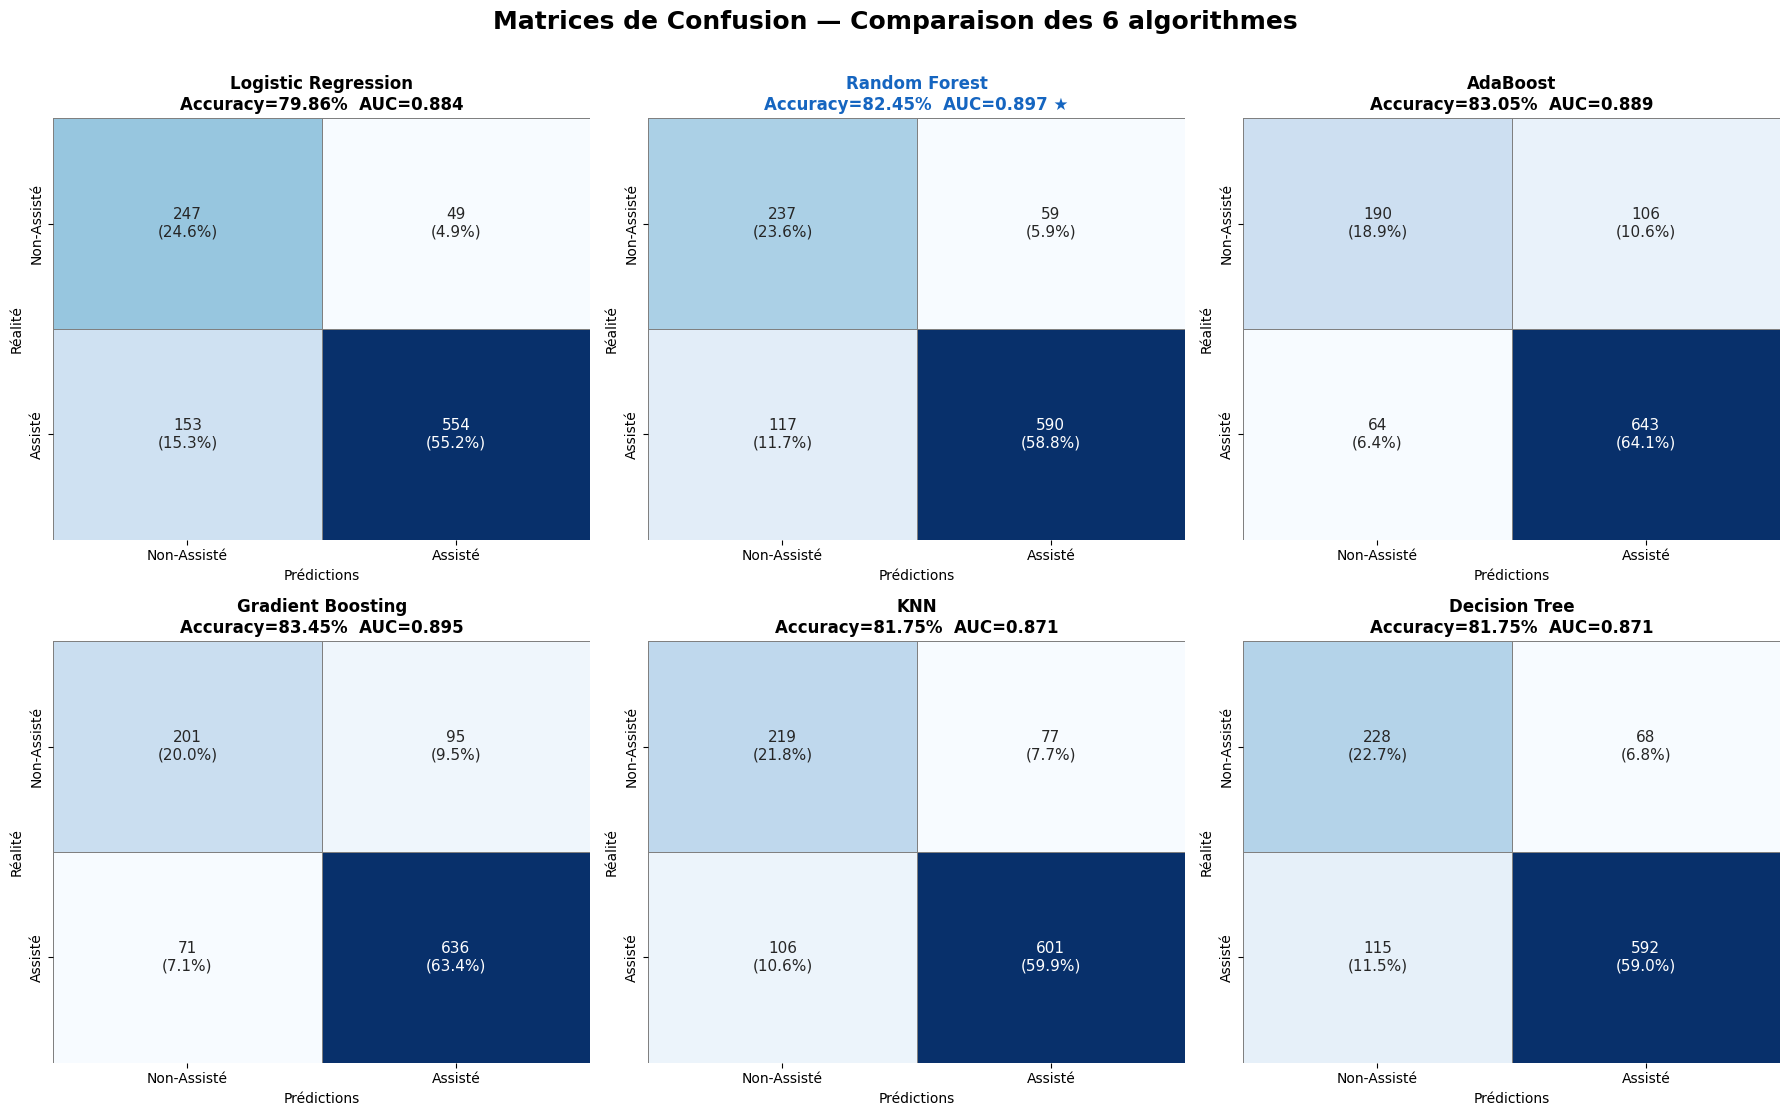

In [31]:
# Déterminer le meilleur modèle
best_name = df_comparaison.iloc[0]['Modèle']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Matrices de Confusion — Comparaison des 6 algorithmes',
             fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (name, model) in enumerate(best_estimators.items()):
    y_pred_i  = model.predict(get_X(name, 'test'))
    y_proba_i = model.predict_proba(get_X(name, 'test'))[:, 1]

    cm_i     = confusion_matrix(Y_test, y_pred_i)
    acc_i    = (y_pred_i == Y_test).mean()
    auc_i    = roc_auc_score(Y_test, y_proba_i)
    total_i  = cm_i.sum()
    annot_i  = np.array([[f'{cm_i[r,c]}\n({cm_i[r,c]/total_i*100:.1f}%)'
                          for c in range(2)] for r in range(2)])

    sns.heatmap(cm_i, annot=annot_i, fmt='', cmap='Blues', ax=axes[i],
                cbar=False, linewidths=0.5, linecolor='grey',
                xticklabels=['Non-Assisté', 'Assisté'],
                yticklabels=['Non-Assisté', 'Assisté'],
                annot_kws={'size': 11})

    titre_couleur = '#1565C0' if name == best_name else 'black'
    axes[i].set_title(
        f'{name}\nAccuracy={acc_i:.2%}  AUC={auc_i:.3f}'
        + (' ★' if name == best_name else ''),
        fontsize=12, fontweight='bold', color=titre_couleur
    )
    axes[i].set_xlabel('Prédictions', fontsize=10)
    axes[i].set_ylabel('Réalité', fontsize=10)

plt.tight_layout()
plt.show()

## Courbe d'apprentissage des 6 algorithmes

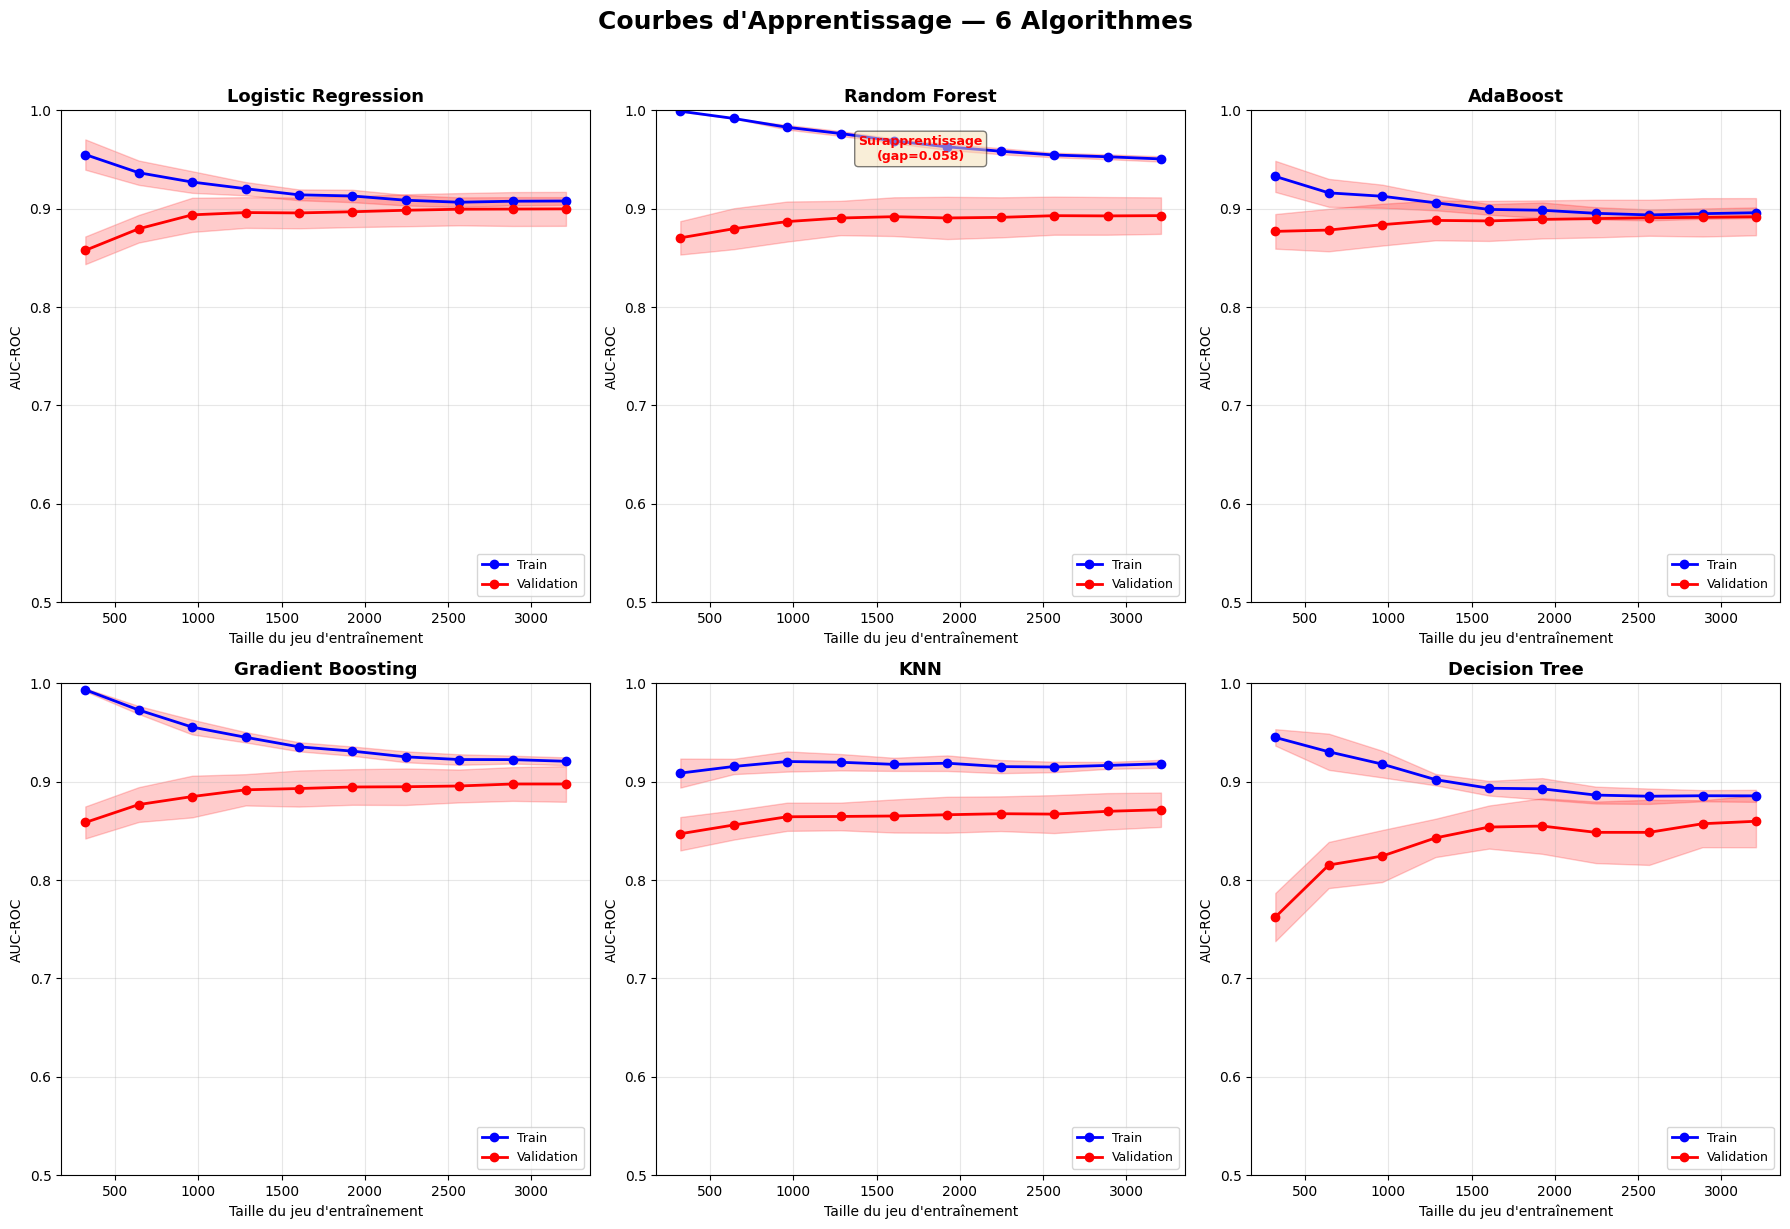

In [32]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Courbes d\'Apprentissage — 6 Algorithmes', fontsize=18, fontweight='bold', y=1.02)
axes = axes.flatten()

for i, (name, model) in enumerate(best_estimators.items()):
    # Utiliser les bonnes données (scalées ou brutes)
    X_data = get_X(name, 'train')
    
    # Calcul des courbes d'apprentissage
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=Y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,                    # 5-fold CV
        scoring='roc_auc',       # Même métrique que votre GridSearch
        n_jobs=-1,
        random_state=42
    )
    
    # Moyennes et écarts-types
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    # Plot
    axes[i].plot(train_sizes, train_mean, 'o-', color='blue', label='Train', linewidth=2)
    axes[i].fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='red')
    
    axes[i].plot(train_sizes, val_mean, 'o-', color='red', label='Validation', linewidth=2)
    axes[i].fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='red')
    
    # Mise en forme
    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Taille du jeu d\'entraînement', fontsize=10)
    axes[i].set_ylabel('AUC-ROC', fontsize=10)
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0.5, 1.0)  # AUC varie entre 0.5 et 1.0
    
    # Détection du surapprentissage (gap train vs validation)
    gap_final = train_mean[-1] - val_mean[-1]
    if gap_final > 0.05:
        axes[i].text(0.5, 0.95, f'Surapprentissage\n(gap={gap_final:.3f})', 
                     transform=axes[i].transAxes, ha='center', va='top',
                     fontsize=9, color='red', fontweight='bold',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### courbe ROC des 6 algorithmes d'apprentissage

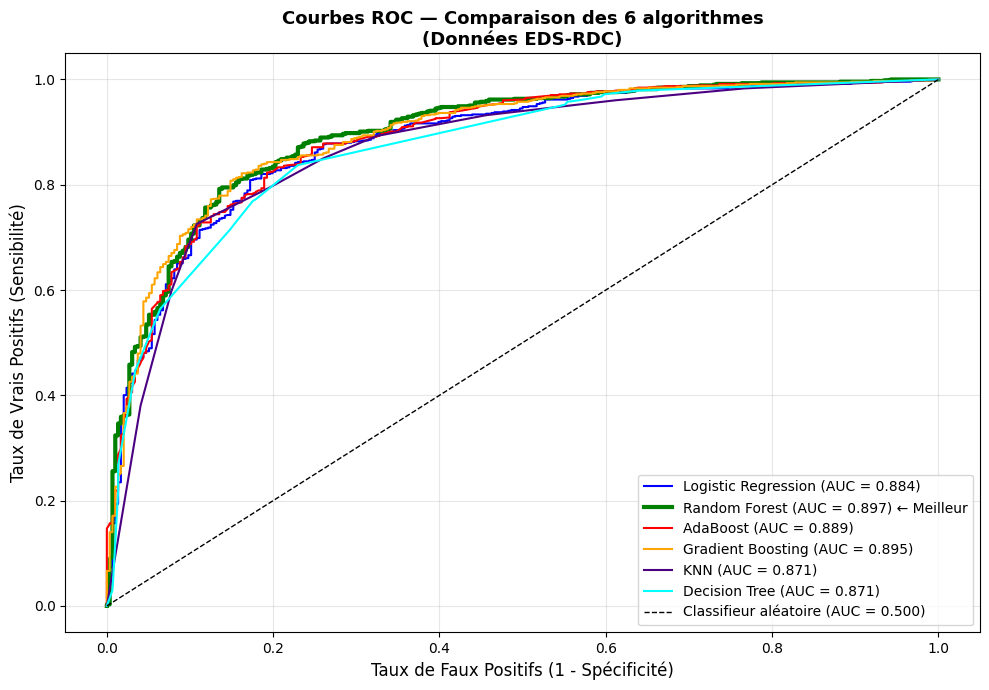

In [33]:
colors = ['blue', 'green', 'red', 'orange', 'indigo', 'cyan']

plt.figure(figsize=(10, 7))

for (name, model), color in zip(best_estimators.items(), colors):
    y_score = model.predict_proba(get_X(name, 'test'))[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_score)
    roc_auc_val  = auc(fpr, tpr)
    # Mettre le meilleur modèle en gras
    lw = 3 if name == best_name else 1.5
    plt.plot(fpr, tpr, color=color, lw=lw,
             label=f'{name} (AUC = {roc_auc_val:.3f})'
                   + (' ← Meilleur' if name == best_name else ''))

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Classifieur aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)',   fontsize=12)
plt.title('Courbes ROC — Comparaison des 6 algorithmes\n(Données EDS-RDC)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Identification automatique du meilleur modèle
best_name  = df_comparaison.iloc[0]['Modèle']
best_model = best_estimators[best_name]
X_cv       = get_X(best_name, 'train')

print(f'Meilleur modèle sélectionné : {best_name}')
print(f'Paramètres optimaux         : {df_comparaison.iloc[0]["Meilleurs params"]}')

# Validation croisée externe (5-Fold stratifiée)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(best_model, X_cv, Y_train, cv=cv_outer, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(best_model, X_cv, Y_train, cv=cv_outer, scoring='accuracy', n_jobs=-1)

print(f'\nRésultats de la validation croisée 5-Fold ({best_name})')
df_cv = pd.DataFrame({
    'Pli'     : [f'Pli {i+1}' for i in range(5)],
    'AUC'     : cv_auc.round(3),
    'Accuracy': cv_acc.round(4)
})
df_cv.loc['MOYENNE'] = ['MOYENNE', cv_auc.mean().round(3), cv_acc.mean().round(4)]
df_cv.loc['ÉCART-TYPE'] = ['ÉCART-TYPE (±)', cv_auc.std().round(3), cv_acc.std().round(4)]
print(df_cv.to_string(index=False))

print(f'\nConclusion : AUC moyen = {cv_auc.mean():.3f} + ou - {cv_auc.std():.3f}')
print(f'             Accuracy moyenne = {cv_acc.mean():.3f}')

Meilleur modèle sélectionné : Random Forest
Paramètres optimaux         : {'max_depth': 10, 'n_estimators': 100}

Résultats de la validation croisée 5-Fold (Random Forest)
           Pli   AUC  Accuracy
         Pli 1 0.883    0.8229
         Pli 2 0.898    0.8367
         Pli 3 0.911    0.8279
         Pli 4 0.884    0.8167
         Pli 5 0.894    0.8304
       MOYENNE 0.894    0.8269
ÉCART-TYPE (±) 0.010    0.0068

Conclusion : AUC moyen = 0.894 + ou - 0.010
             Accuracy moyenne = 0.827


In [35]:
y_pred_best  = best_model.predict(get_X(best_name, 'test'))
y_proba_best = best_model.predict_proba(get_X(best_name, 'test'))[:, 1]

print(f'Rapport de classification — {best_name}')
print(classification_report(
    Y_test, y_pred_best,
    target_names=['Non-Assisté (0)', 'Assisté (1)']
))
print(f'AUC Score : {roc_auc_score(Y_test, y_proba_best):.4f}')

Rapport de classification — Random Forest
                 precision    recall  f1-score   support

Non-Assisté (0)       0.67      0.80      0.73       296
    Assisté (1)       0.91      0.83      0.87       707

       accuracy                           0.82      1003
      macro avg       0.79      0.82      0.80      1003
   weighted avg       0.84      0.82      0.83      1003

AUC Score : 0.8968


In [36]:
import docx
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap


#  PRÉPARATION DES DONNÉES ET ENTRAÎNEMENT DU RANDOM FOREST


# Chargement du fichier nettoyé issu de la partie A (comme dans votre notebook)
data = pd.read_csv('PrCMIR71FL.csv', sep=';')

# Application de l'ordre personnalisé pour définir les modalités de référence (la première de la liste)
cat_vars = ['V013', 'V024', 'V025', 'V106', 'V130', 'V190', 'V701', 
            'ANC', 'Media_exposure', 'autonomie_decisionnelle', 'attitude_violence', 'parite']

custom_order = {
    'V013': [1, 2, 3, 4, 5, 6, 7],
    'V024': [5, 1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12],  # 5 = Extrême-Nord en référence
    'V025': [2, 1],                                   # 2 = Rural en référence
    'V106': [0, 1, 2, 3],                             # 0 = Aucun niveau en référence
    'V130': [4, 1, 2, 3, 5, 7, 96],                   # 4 = Musulman en référence
    'V190': [1, 2, 3, 4, 5],                          # 1 = Le plus pauvre en référence
    'V701': [0, 1, 2, 3, 8],                          # 0 = Aucun niveau en référence
    'ANC': [0, 1],
    'Media_exposure': [0, 1],
    'autonomie_decisionnelle': [1, 2, 3],
    'attitude_violence': [1, 0],
    'parite': [3, 1, 2]
}

# Dummification identique à votre processus
data_dummies = data.copy()
for var in cat_vars:
    data_dummies[var] = pd.Categorical(data_dummies[var], categories=custom_order[var], ordered=True)
    dummies = pd.get_dummies(data_dummies[var], prefix=var, drop_first=True)
    data_dummies = pd.concat([data_dummies, dummies], axis=1)

# Extraction des features créées par get_dummies (exclut les variables d'origine et d'identification)
features = []
for var in cat_vars:
    features.extend([col for col in data_dummies.columns if f"{var}_" in col])

X = data_dummies[features]
y = data_dummies['SBA']  # Cible : Accouchement qualifié

# Division Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Entraînement du modèle Random Forest
# Note : Vous pouvez remplacer par votre objet 'best_model' après votre GridSearchCV
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight='balanced')
rf_model.fit(X_train, y_train)


# CALCUL DES VALEURS SHAP GLOBAL


# Utilisation de TreeExplainer (parfait pour les modèles d'arbres comme Random Forest)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Pour une classification binaire (0/1), on extrait la contribution moyenne pour la classe 1 (SBA=1)
if isinstance(shap_values, list):
    # Selon la version de la librairie shap, elle retourne une liste [classe 0, classe 1]
    shap_importance = np.abs(shap_values[1]).mean(axis=0)
else:
    # Pour les versions récentes de SHAP sur les TreeEnsemble
    if len(shap_values.shape) == 3:  # Format (individus, variables, classes)
        shap_importance = np.abs(shap_values[:, :, 1]).mean(axis=0)
    else:
        shap_importance = np.abs(shap_values).mean(axis=0)

# Stockage dans un dictionnaire reliant la variable dummifiée à son importance moyenne SHAP
shap_dict = dict(zip(X_test.columns, shap_importance))


# STRUCTURE ET CORRESPONDANCE AVEC L'ANALYSE BIVARIÉE


# Définition de la table de correspondance selon vos codes EDS réels
data_structure = [
    {"type": "variable", "name": "Groupe d'âge (V013)"},
    {"type": "modalite", "name": "15-19 ans", "col_name": "V013_1"}, # Sera marquée ref
    {"type": "modalite", "name": "20-24 ans", "col_name": "V013_2"},
    {"type": "modalite", "name": "25-29 ans", "col_name": "V013_3"},
    {"type": "modalite", "name": "30-34 ans", "col_name": "V013_4"},
    {"type": "modalite", "name": "35-39 ans", "col_name": "V013_5"},
    {"type": "modalite", "name": "40-44 ans", "col_name": "V013_6"},
    {"type": "modalite", "name": "45-49 ans", "col_name": "V013_7"},

    {"type": "variable", "name": "Région de résidence (V024)"},
    {"type": "modalite", "name": "Extrême-Nord", "col_name": "V024_5"}, # ref
    {"type": "modalite", "name": "Adamaoua", "col_name": "V024_1"},
    {"type": "modalite", "name": "Centre (sans Yaoundé)", "col_name": "V024_2"},
    {"type": "modalite", "name": "Douala", "col_name": "V024_3"},
    {"type": "modalite", "name": "Est", "col_name": "V024_4"},
    {"type": "modalite", "name": "Littoral (sans Douala)", "col_name": "V024_6"},
    {"type": "modalite", "name": "Nord", "col_name": "V024_7"},
    {"type": "modalite", "name": "Nord-Ouest", "col_name": "V024_8"},
    {"type": "modalite", "name": "Ouest", "col_name": "V024_9"},
    {"type": "modalite", "name": "Sud", "col_name": "V024_10"},
    {"type": "modalite", "name": "Sud-Ouest", "col_name": "V024_11"},
    {"type": "modalite", "name": "Yaoundé", "col_name": "V024_12"},

    {"type": "variable", "name": "Milieu de résidence (V025)"},
    {"type": "modalite", "name": "Rural", "col_name": "V025_2"}, # ref
    {"type": "modalite", "name": "Urbain", "col_name": "V025_1"},

    {"type": "variable", "name": "Niveau d'éducation de la femme (V106)"},
    {"type": "modalite", "name": "Aucun niveau", "col_name": "V106_0"}, # ref
    {"type": "modalite", "name": "Primaire", "col_name": "V106_1"},
    {"type": "modalite", "name": "Secondaire", "col_name": "V106_2"},
    {"type": "modalite", "name": "Supérieur", "col_name": "V106_3"},

    {"type": "variable", "name": "Quintile de richesse (V190)"},
    {"type": "modalite", "name": "Le plus pauvre (Poorest)", "col_name": "V190_1"}, # ref
    {"type": "modalite", "name": "Pauvre (Poorer)", "col_name": "V190_2"},
    {"type": "modalite", "name": "Moyen (Middle)", "col_name": "V190_3"},
    {"type": "modalite", "name": "Riche (Richer)", "col_name": "V190_4"},
    {"type": "modalite", "name": "Le plus riche (Richest)", "col_name": "V190_5"},

    {"type": "variable", "name": "Niveau d'éducation du mari (V701)"},
    {"type": "modalite", "name": "Aucun niveau", "col_name": "V701_0"}, # ref
    {"type": "modalite", "name": "Primaire", "col_name": "V701_1"},
    {"type": "modalite", "name": "Secondaire", "col_name": "V701_2"},
    {"type": "modalite", "name": "Supérieur", "col_name": "V701_3"},
    {"type": "modalite", "name": "Je ne sais pas", "col_name": "V701_8"},

    {"type": "variable", "name": "Suivi des visites prénatales (ANC)"},
    {"type": "modalite", "name": "Aucune visite / Non", "col_name": "ANC_0"}, # ref
    {"type": "modalite", "name": "Au moins 1 visite / Oui", "col_name": "ANC_1"},

    {"type": "variable", "name": "Exposition aux médias (Media_exposure)"},
    {"type": "modalite", "name": "Non exposé", "col_name": "Media_exposure_0"}, # ref
    {"type": "modalite", "name": "Exposé aux médias", "col_name": "Media_exposure_1"}
]


# FONCTIONS DE MISE EN FORME WORD (MÊME STYLE QUE VOTRE TABLEAU BIVARIÉ)

def set_cell_background(cell, fill_hex):
    tc_pr = cell._tc.get_or_add_tcPr()
    shd = OxmlElement('w:shd')
    shd.set(qn('w:val'), 'clear')
    shd.set(qn('w:color'), 'auto')
    shd.set(qn('w:fill'), fill_hex)
    tc_pr.append(shd)

def set_cell_margins(cell, top=100, bottom=100, left=150, right=150):
    tc_pr = cell._tc.get_or_add_tcPr()
    tc_mar = OxmlElement('w:tcMar')
    for m_type, m_val in [('top', top), ('bottom', bottom), ('left', left), ('right', right)]:
        node = OxmlElement(f'w:{m_type}')
        node.set(qn('w:w'), str(m_val))
        node.set(qn('w:type'), 'dxa')
        tc_mar.append(node)
    tc_pr.append(tc_mar)

def set_table_borders(table):
    tbl_pr = table._tbl.tblPr
    tbl_borders = OxmlElement('w:tblBorders')
    for b_name in ['top', 'bottom', 'insideH']:
        border = OxmlElement(f'w:{b_name}')
        border.set(qn('w:val'), 'single')
        border.set(qn('w:sz'), '4')  # 0.5 pt
        border.set(qn('w:color'), 'D3D3D3')
        tbl_borders.append(border)
    for b_name in ['left', 'right', 'insideV']:
        border = OxmlElement(f'w:{b_name}')
        border.set(qn('w:val'), 'none')
        tbl_borders.append(border)
    tbl_pr.append(tbl_borders)


# GÉNÉRATION DU DOCUMENT DOCX

doc = docx.Document()
doc.styles['Normal'].font.name = 'Calibri'
doc.styles['Normal'].font.size = Pt(11)

# Titre du tableau
title_p = doc.add_paragraph()
title_p.paragraph_format.space_after = Pt(12)
run_title = title_p.add_run("Tableau 3 : Importance globale des modalités explicatives (Valeurs SHAP du Random Forest)")
run_title.bold = True
run_title.font.size = Pt(11)

# Création du tableau épuré à 2 colonnes
table = doc.add_table(rows=1, cols=2)
table.alignment = WD_TABLE_ALIGNMENT.CENTER
set_table_borders(table)

hdr_cells = table.rows[0].cells
hdr_titles = ["Variable / Catégorie de réponse", "Importance SHAP globale (|SHAP value| moyenne)"]
col_widths = [Inches(4.5), Inches(2.2)]

for i, title in enumerate(hdr_titles):
    hdr_cells[i].text = title
    hdr_cells[i].width = col_widths[i]
    set_cell_background(hdr_cells[i], "EFEFEF")  # Gris d'en-tête académique
    set_cell_margins(hdr_cells[i], top=120, bottom=120, left=150, right=150)
    p = hdr_cells[i].paragraphs[0]
    p.alignment = WD_ALIGN_PARAGRAPH.LEFT if i == 0 else WD_ALIGN_PARAGRAPH.RIGHT
    p.runs[0].font.bold = True
    p.runs[0].font.size = Pt(10)

# Insertion des lignes de données
for row_data in data_structure:
    row_cells = table.add_row().cells
    for i in range(2):
        row_cells[i].width = col_widths[i]
        set_cell_margins(row_cells[i], top=80, bottom=80, left=150, right=150)
        
    p0 = row_cells[0].paragraphs[0]
    p1 = row_cells[1].paragraphs[0]
    p1.alignment = WD_ALIGN_PARAGRAPH.RIGHT
    
    if row_data["type"] == "variable":
        # Entête du groupe de variables (Gras sur fond grisé très clair)
        p0.add_run(row_data["name"]).font.bold = True
        for cell in row_cells:
            set_cell_background(cell, "F9F9F9")
    else:
        # Modalité (avec un retrait de 0.3 pouce identique à votre bivarié)
        p0.paragraph_format.left_indent = Inches(0.3)
        p0.add_run(row_data["name"])
        
        col_key = row_data["col_name"]
        if col_key in shap_dict:
            # La modalité est présente dans X_test, on extrait sa valeur
            p1.add_run(f"{shap_dict[col_key]:.4f}")
        else:
            # Modalité absente de la matrice due au drop_first : c'est la référence !
            run_ref = p1.add_run("ref.")
            run_ref.font.italic = True
            run_ref.font.color.rgb = docx.shared.RGBColor(140, 140, 140)
            
    for p in [p0, p1]:
        if p.runs:
            p.runs[0].font.size = Pt(9.5)

# Enregistrement
output_filename = "Tableau3_SHAP_Random_Forest.docx"
doc.save(output_filename)
print(f"Le fichier Word '{output_filename}' a bien été généré avec succès !")

Le fichier Word 'Tableau3_SHAP_Random_Forest.docx' a bien été généré avec succès !
